In [2]:
import os
os.chdir("D:/Projects/volatility-radar")

In [3]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load the saved model
import joblib
final_model = joblib.load('src/models/volatility_radar_xgb.pkl')


df = pd.read_csv("data/final_cleaned_data/full_features.csv")

FEATURE_COLS = [
    'pair', 'day_of_week', 'month', 'week_of_year', 'is_month_end', 'is_month_start',
    'max_up_pips', 'max_down_pips', 'max_profit', 'max_loss', 'daily_return',
    'return_3d', 'return_5d', 'return_10d', 'rolling_std_5', 'rolling_std_10',
    'rolling_std_20', 'rsi_14', 'atr_14', 'momentum_5d', 'momentum_10d',
    'dist_from_mean_20d', 'daily_range', 'candle_body', 'upper_wick', 'lower_wick',
    'high_impact_count', 'medium_impact_count', 'low_impact_count', 'max_z_score',
    'sum_signal', 'dominant_direction', 'max_surprise_z', 'sum_signal_surprise'
]

X_full = df[FEATURE_COLS]

# TreeExplainer is optimized for XGBoost
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_full)

# shap_values.shape → (4023, 34, 3) — rows × features × classes
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (4023, 34, 3)


In [4]:
# mean absolute SHAP value per feature across all classes
shap_importance = np.abs(shap_values.values).mean(axis=2).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': shap_importance
}).sort_values('importance', ascending=False)

print(feature_importance_df.to_string(index=False))

            feature  importance
     rolling_std_20    0.130626
      rolling_std_5    0.077699
        day_of_week    0.072978
     rolling_std_10    0.071322
             atr_14    0.069303
         max_profit    0.065537
             rsi_14    0.065212
        daily_range    0.058934
        max_z_score    0.058328
     max_surprise_z    0.057851
           max_loss    0.057822
          return_3d    0.057788
 dist_from_mean_20d    0.049136
         lower_wick    0.047950
         return_10d    0.046899
       momentum_10d    0.045178
        momentum_5d    0.045002
       week_of_year    0.044370
 dominant_direction    0.044200
         upper_wick    0.043634
medium_impact_count    0.041818
         sum_signal    0.041751
sum_signal_surprise    0.041037
   low_impact_count    0.040934
      max_down_pips    0.040040
        candle_body    0.038625
          return_5d    0.037756
       daily_return    0.037268
        max_up_pips    0.027950
  high_impact_count    0.019914
        

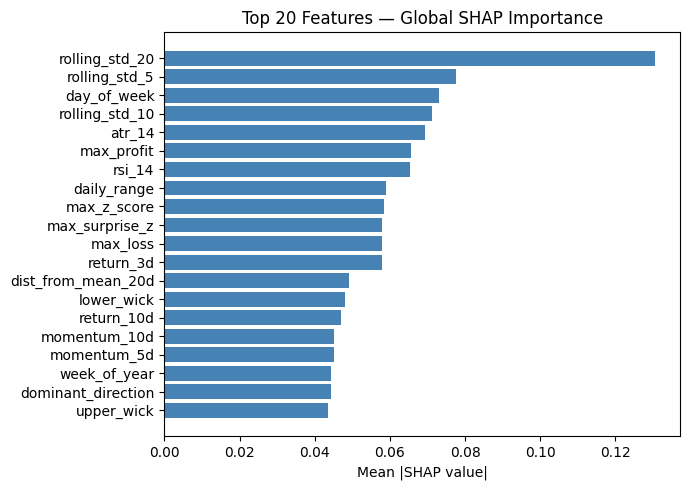

Saved.


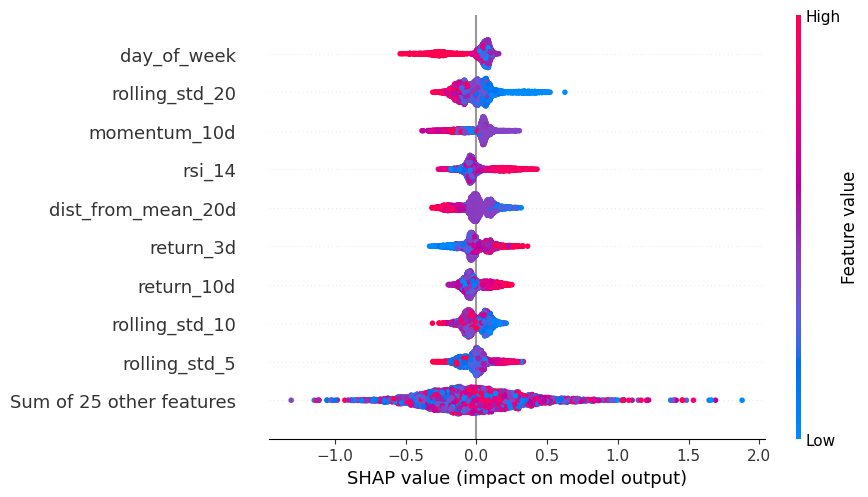

<Figure size 640x480 with 0 Axes>

In [5]:
os.makedirs('reports', exist_ok = True)

# Global feature importance bar plot
plt.figure(figsize=(7, 5))
plt.barh(
    feature_importance_df['feature'][:20],
    feature_importance_df['importance'][:20],
    color='steelblue'
)
plt.xlabel('Mean |SHAP value|')
plt.title('Top 20 Features — Global SHAP Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('reports/shap_global_importance.png', dpi=150)
plt.show()
print("Saved.")

# Beeswarm plot — shows direction of impact, not just magnitude
shap.plots.beeswarm(shap_values[:, :, 0], max_display=10)  # class 0 = Bearish
plt.savefig('reports/shap_beeswarm_bearish.png', dpi=150, bbox_inches='tight')
plt.show()

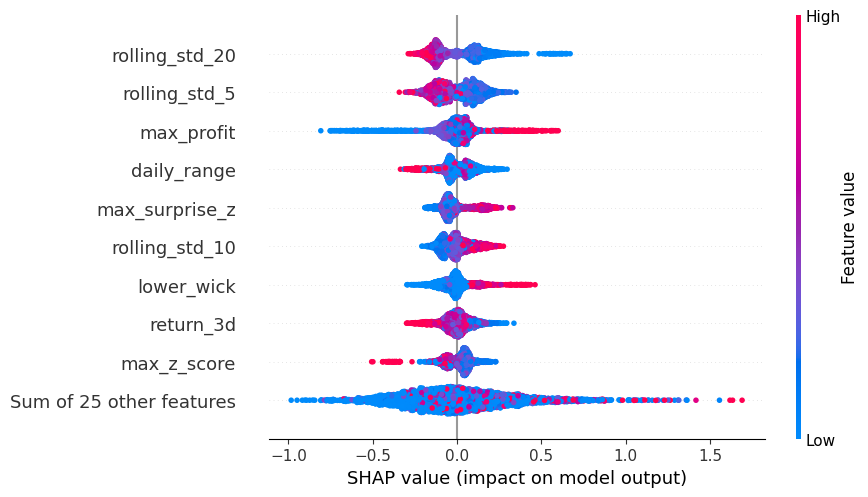

<Figure size 640x480 with 0 Axes>

In [6]:
shap.plots.beeswarm(shap_values[:, :, 2], max_display=10)  # class 2 = Bullish
plt.savefig('reports/shap_beeswarm_bullish.png', dpi=150, bbox_inches='tight')
plt.show()